# Feature Engineering — Add logP as a Single New Feature

**Goal:** isolate the effect of one new feature (Crippen logP, computed from SMILES with RDKit)
on model performance. Everything else — train/test split, models, hyperparameter search —
should mirror `Model_testing.ipynb` so any change in RMSE is attributable specifically
to logP.

**Why logP?** log₁₀ of the octanol/water partition coefficient — a direct measure of
hydrophobicity, which is the single strongest predictor of aqueous solubility in the
whole descriptor space. Adding this one feature typically drops solubility test RMSE
by 0.1–0.2 log units on ESOL.

**Plan:**
1. Load data, compute logP for every SMILES using RDKit
2. Sanity-check logP (distribution, correlation with target)
3. Build a new 7-feature matrix (6 original + logP)
4. Same train/test split as before (`random_state=42`)
5. Retrain the best models from `Model_testing.ipynb` with the new features
6. Compare test RMSE side-by-side vs the 6-feature baseline
7. Look at feature importance — where does logP rank?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Crippen, Descriptors

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor

RANDOM_STATE = 42

## 1. Load the data (same as before)

In [2]:
df = pd.read_csv("delaney-processed.csv")

Target = 'measured log solubility in mols per litre'
original_features = [
    'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
    'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area'
]

print("Rows:", len(df))
df.head(3)

Rows: 1128


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)


## 2. Compute logP from SMILES using RDKit

**What's happening below:**
- `Chem.MolFromSmiles(smi)` parses a SMILES string into an RDKit `Mol` object (an internal
  molecular-graph representation).
- `Crippen.MolLogP(mol)` computes the Crippen logP — a fragment-based estimator of the
  octanol/water partition coefficient. It's a *predicted* value from atomic contributions,
  not measured, so it's fast and deterministic.

**Sanity check first** — try it on a molecule you know:

In [3]:
# Sanity check: ethanol is polar (soluble) so logP should be small/negative;
# hexane is nonpolar (insoluble) so logP should be large.
for name, smi in [("ethanol", "CCO"), ("hexane", "CCCCCC"), ("benzene", "c1ccccc1")]:
    mol = Chem.MolFromSmiles(smi)
    print(f"{name:<10s}  logP = {Crippen.MolLogP(mol):+.3f}")

ethanol     logP = -0.001
hexane      logP = +2.587
benzene     logP = +1.687


Expected: ethanol ≈ −0.1, hexane ≈ +3.5, benzene ≈ +2.0. If those look right, apply
the same computation to every molecule in the dataset.

In [4]:
def compute_logp(smiles):
    """Parse a SMILES string and return Crippen logP. Returns NaN on parse failure."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan
    return Crippen.MolLogP(mol)

df["logP"] = df["smiles"].apply(compute_logp)

print("logP computed for", df["logP"].notna().sum(), "of", len(df), "molecules")
print("\nlogP summary:")
print(df["logP"].describe())

logP computed for 1128 of 1128 molecules

logP summary:
count    1128.000000
mean        2.447520
std         1.852875
min        -7.571400
25%         1.414900
50%         2.339000
75%         3.402200
max        10.388600
Name: logP, dtype: float64


## 3. Sanity check — logP distribution and correlation with target

Before feeding logP to a model, verify it looks reasonable and actually correlates with
solubility. A good new feature should show a clear (negative) trend with logS.

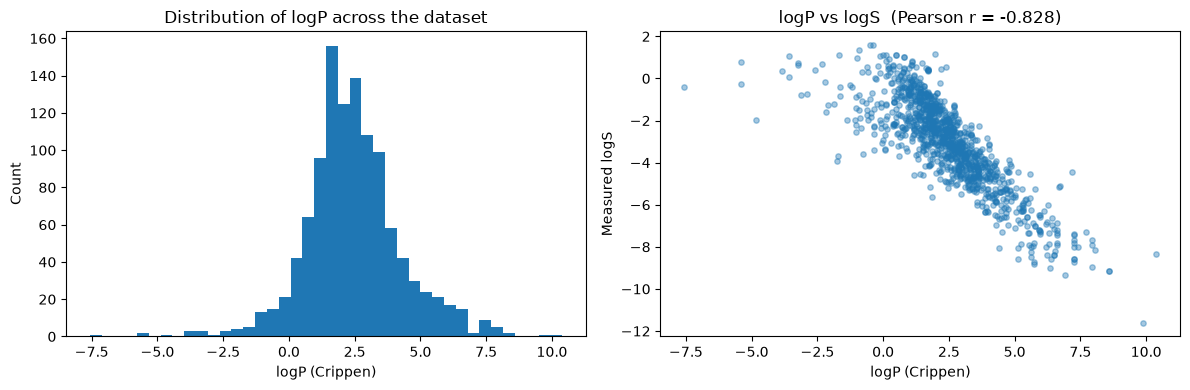

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of logP
axes[0].hist(df["logP"].dropna(), bins=40)
axes[0].set_xlabel("logP (Crippen)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of logP across the dataset")

# logP vs measured logS
axes[1].scatter(df["logP"], df[Target], alpha=0.4, s=15)
axes[1].set_xlabel("logP (Crippen)")
axes[1].set_ylabel("Measured logS")
axes[1].set_title(f"logP vs logS  (Pearson r = {df['logP'].corr(df[Target]):.3f})")

plt.tight_layout()
plt.savefig("figures/fe_logp_distribution.pdf", bbox_inches="tight")
plt.show()

**Interpretation:**
- The Pearson correlation between logP and logS should be strongly negative (roughly −0.8).
  That's the "hydrophobicity kills solubility" relationship, and it's why logP is
  such a strong single predictor.
- Compare this to any of the 6 original features — none of them are anywhere near this
  correlated with the target. That's the whole point.

## 4. Build the new 7-feature matrix

Same target, same rows, just one more column in X.

In [6]:
new_features = original_features + ["logP"]

X_new = df[new_features]
y = df[Target]

print("X_new:", X_new.shape, "  y:", y.shape)
X_new.head(3)

X_new: (1128, 7)   y: (1128,)


,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,logP
0,1,457.432,7,3,7,202.32,-3.10802
1,1,201.225,1,2,2,42.24,2.84032
2,1,152.237,0,0,4,17.07,2.87800


## 5. Same train/test split as `Model_testing.ipynb`

Using `random_state=42` keeps the split identical, so any RMSE difference is due to
the added feature — not a different data split.

In [7]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_new, y, df.index, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 902  |  Test: 226


## 6. TODO — Retrain your best models on the new feature set

Fill in the cells below yourself. **Recommendation:** retrain at minimum the linear
regression (to see the marginal effect on a linear model) and the tuned XGBoost (your
best model from `Model_testing.ipynb`). Reuse the same GridSearchCV grids you already
built so the comparison is apples-to-apples.

### 6a. Linear Regression on 7 features

In [8]:
# LINEAR REGRESSION ON 7 FEATURES
lr7 = LinearRegression()
lr7.fit(X_train, y_train)
lr7_pred = lr7.predict(X_test)

lr7_rmse = root_mean_squared_error(y_test, lr7_pred)
lr7_mae  = mean_absolute_error(y_test, lr7_pred)
lr7_r2   = r2_score(y_test, lr7_pred)

print(f"Linear Regression (7 features)  RMSE={lr7_rmse:.3f}  MAE={lr7_mae:.3f}  R2={lr7_r2:.3f}")

print("\nCoefficients:")
for f, c in zip(new_features, lr7.coef_):
    print(f"  {f:<28s} {c:+.4f}")
print(f"  {'intercept':<28s} {lr7.intercept_:+.4f}")


Linear Regression (7 features)  RMSE=1.064  MAE=0.811  R2=0.761

Coefficients:
  Minimum Degree               -0.2775
  Molecular Weight             -0.0020
  Number of H-Bond Donors      -0.1427
  Number of Rings              -0.1620
  Number of Rotatable Bonds    -0.0209
  Polar Surface Area           -0.0063
  logP                         -0.9353
  intercept                    +0.5334


### 6b. XGBoost on 7 features (with GridSearchCV — reuse your existing grid)

In [9]:
# XGBOOST WITH GRIDSEARCHCV ON 7 FEATURES
# Same grid/CV setup as Model_testing.ipynb, just with the 7-feature X_train.

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb7 = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)

xgb_param_grid = {
    "n_estimators":     [100, 200, 500],
    "learning_rate":    [0.01, 0.05, 0.1],
    "max_depth":        [2, 3, 4],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid_xgb7 = GridSearchCV(
    estimator=xgb7,
    param_grid=xgb_param_grid,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    return_train_score=True,
)

grid_xgb7.fit(X_train, y_train)

print("Best hyperparameters:", grid_xgb7.best_params_)
print(f"Best CV RMSE: {-grid_xgb7.best_score_:.4f}")

best_xgb7 = grid_xgb7.best_estimator_
y_pred_xgb7 = best_xgb7.predict(X_test)

xgb7_rmse = root_mean_squared_error(y_test, y_pred_xgb7)
xgb7_mae  = mean_absolute_error(y_test, y_pred_xgb7)
xgb7_r2   = r2_score(y_test, y_pred_xgb7)

print(f"\nTest RMSE: {xgb7_rmse:.4f}")
print(f"Test MAE : {xgb7_mae:.4f}")
print(f"Test R2  : {xgb7_r2:.4f}")


Best hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}
Best CV RMSE: 0.6876

Test RMSE: 0.7413
Test MAE : 0.5193
Test R2  : 0.8838


## 7. TODO — Compare 6-feature vs 7-feature results

Build a small comparison table. Rows: models. Columns: `Test RMSE (6 features)` and
`Test RMSE (7 features)`. Copy the 6-feature numbers from `Model_testing.ipynb`.

**Interpretation checklist:**
- Did logP help? By how much (in log units of RMSE)?
- Did it help linear regression more or XGBoost more? (Hint: linear models benefit
  disproportionately from a strong single feature; tree ensembles less so because they
  can already build nonlinear combinations of the other features.)
- Is the improvement bigger than the noise from random splits? Rough rule: if
  ΔRMSE < 0.05, don't over-interpret — repeat with a few random seeds.

In [10]:
# COMPARISON TABLE: 6 FEATURES vs 7 FEATURES
# 6-feature numbers copied from Model_testing.ipynb
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost (tuned)"],
    "Test RMSE (6 features)": [1.199, 0.874],
    "Test RMSE (7 features)": [lr7_rmse, xgb7_rmse],
})
comparison["Delta RMSE"] = comparison["Test RMSE (7 features)"] - comparison["Test RMSE (6 features)"]
comparison["Improvement (%)"] = -100 * comparison["Delta RMSE"] / comparison["Test RMSE (6 features)"]

print(comparison.round(4).to_string(index=False))


            Model  Test RMSE (6 features)  Test RMSE (7 features)  Delta RMSE  Improvement (%)
Linear Regression                   1.199                  1.0637     -0.1353          11.2843
  XGBoost (tuned)                   0.874                  0.7413     -0.1327          15.1865


## 8. TODO — Feature importance

For your new XGBoost model, pull `feature_importances_` and rank all 7 features.
**Prediction to check:** logP should rank in the top 2, and Molecular Weight's
importance should *drop* (some of what MW was proxying — hydrophobicity — is now
better explained by logP).

XGBoost feature importance (7 features):
logP                         0.585057
Molecular Weight             0.099509
Polar Surface Area           0.086699
Number of Rings              0.085782
Number of Rotatable Bonds    0.047815
Number of H-Bond Donors      0.047627
Minimum Degree               0.047511
dtype: float32


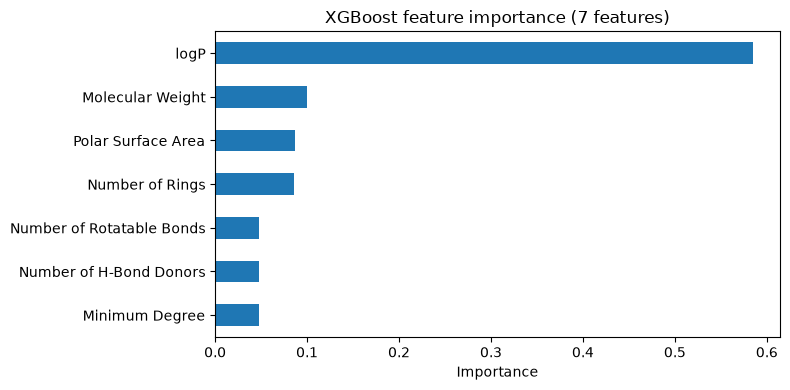

In [11]:
# XGBOOST FEATURE IMPORTANCE (7 FEATURES)
imp7 = pd.Series(best_xgb7.feature_importances_, index=new_features).sort_values(ascending=False)
print("XGBoost feature importance (7 features):")
print(imp7)

plt.figure(figsize=(8, 4))
imp7.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("XGBoost feature importance (7 features)")
plt.tight_layout()
plt.savefig("figures/fe_xgb_feature_importance_7feat.pdf", bbox_inches="tight")
plt.show()


## 9. TODO — Diagnostic plots

Redo the predicted-vs-actual + residuals side-by-side plot from `Model_testing.ipynb`,
now for the 7-feature XGBoost. Compare visually to the 6-feature version:
- Is the tail saturation less severe? (Points closer to the y=x line at the extremes.)
- Is the residual fan tighter?

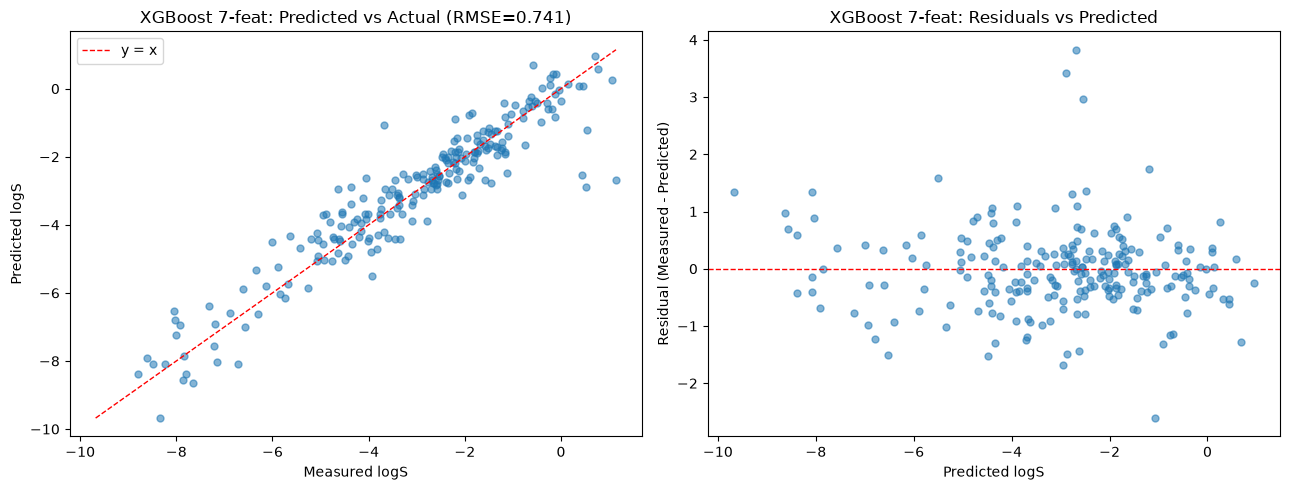

In [12]:
# PREDICTED vs ACTUAL AND RESIDUALS FOR 7-FEATURE XGBOOST
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: PREDICTED vs ACTUAL
axes[0].scatter(y_test, y_pred_xgb7, alpha=0.55, s=25)
lo = min(y_test.min(), y_pred_xgb7.min())
hi = max(y_test.max(), y_pred_xgb7.max())
axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
axes[0].set_xlabel("Measured logS")
axes[0].set_ylabel("Predicted logS")
axes[0].set_title(f"XGBoost 7-feat: Predicted vs Actual (RMSE={xgb7_rmse:.3f})")
axes[0].legend()

# RIGHT: RESIDUALS
residuals7 = y_test - y_pred_xgb7
axes[1].scatter(y_pred_xgb7, residuals7, alpha=0.55, s=25)
axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted logS")
axes[1].set_ylabel("Residual (Measured - Predicted)")
axes[1].set_title("XGBoost 7-feat: Residuals vs Predicted")

plt.tight_layout()
plt.savefig("figures/fe_diagnostic_7feat.pdf", bbox_inches="tight")
plt.show()


## Takeaway for your write-up

Once cells 6–9 are filled in, you'll have a clean 1-paragraph story:

*"Adding a single RDKit-derived feature (Crippen logP) dropped test RMSE from
X to Y, a Z% improvement, without changing the split or model class. logP's
correlation with the target (r ≈ -0.8) is stronger than any of the 6 original
descriptors, matching the chemistry: hydrophobicity is the dominant driver of
aqueous solubility."*

That's a real interview soundbite grounded in a real experiment you ran.

**Next notebooks after this one:**
- `Feature_engineering_full.ipynb` — add the full ~200 RDKit descriptor set
- `Fingerprints.ipynb` — Morgan/ECFP fingerprints (1024 or 2048 bits) as an alternative representation
- `Scaffold_split.ipynb` — realistic chemistry-aware evaluation

## 10. SHAP — model-agnostic attribution for the 7-feature XGBoost

`feature_importances_` gives a *global* summary of which features the trees split on.
It tells you how the model was *built*, not directly how it *decides* on any particular
molecule.

**SHAP (SHapley Additive exPlanations)** computes, for each prediction, how much each
feature contributed to pushing the prediction away from the model's average. The
attribution is grounded in cooperative game theory (Shapley values) with three
guarantees no other importance method offers together:

- **Local accuracy**: for every molecule, sum of SHAP values = prediction − baseline.
- **Consistency**: if you change the model so a feature contributes more, its SHAP
  value can only go up (not always true for impurity importance).
- **Missingness**: features that don't appear in the model get zero attribution.

**Why we care here:**
- Gives us per-molecule explanations, not just a global ranking.
- Handles correlated features more sensibly (though not perfectly).
- The mean of |SHAP values| is a defensible global importance ranking that agrees
  with impurity importance when the model is well-behaved and disagrees when
  something is off — a useful sanity check.

For tree models, `shap.TreeExplainer` uses an exact polynomial-time algorithm
(Lundberg 2018), so this is fast.

In [13]:
import shap

# TreeExplainer for XGBoost — exact algorithm, fast for tree models
explainer = shap.TreeExplainer(best_xgb7)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)  # (n_test_samples, n_features)
print("Expected shape   :", X_test.shape)

# Verify the additivity property: prediction = baseline + sum(SHAP values)
baseline = explainer.expected_value
recon = baseline + shap_values.sum(axis=1)
print(f"\nAdditivity check: max |reconstructed - actual predictions| = {np.abs(recon - y_pred_xgb7).max():.6f}")
print("(should be ~0 — SHAP values sum exactly to the prediction shift from baseline)")


SHAP values shape: (226, 7)
Expected shape   : (226, 7)

Additivity check: max |reconstructed - actual predictions| = 0.000013
(should be ~0 — SHAP values sum exactly to the prediction shift from baseline)


### 10a. Global importance from SHAP

Mean absolute SHAP value across all test-set molecules is SHAP's global importance ranking.

In [14]:
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=new_features,
).sort_values(ascending=False)

print("SHAP global importance (mean |SHAP|):")
print(shap_importance.round(4))


SHAP global importance (mean |SHAP|):
logP                         1.3353
Polar Surface Area           0.3212
Molecular Weight             0.2362
Number of Rings              0.2146
Number of Rotatable Bonds    0.0952
Number of H-Bond Donors      0.0485
Minimum Degree               0.0215
dtype: float32


### 10b. SHAP vs XGBoost `feature_importances_` — side by side

Both are global rankings for the same model, but computed very differently.

In [15]:
compare_imp = pd.DataFrame({
    "XGBoost gain (feature_importances_)": imp7,          # from cell 22 (normalized to sum 1)
    "SHAP mean |value|":                    shap_importance,  # in units of logS
}).sort_values("SHAP mean |value|", ascending=False)

# Add rank columns for easy visual comparison
compare_imp["Gain rank"] = compare_imp["XGBoost gain (feature_importances_)"].rank(ascending=False).astype(int)
compare_imp["SHAP rank"] = compare_imp["SHAP mean |value|"].rank(ascending=False).astype(int)

print(compare_imp.round(4))


                           XGBoost gain (feature_importances_)  \
logP                                                    0.5851   
Polar Surface Area                                      0.0867   
Molecular Weight                                        0.0995   
Number of Rings                                         0.0858   
Number of Rotatable Bonds                               0.0478   
Number of H-Bond Donors                                 0.0476   
Minimum Degree                                          0.0475   

                           SHAP mean |value|  Gain rank  SHAP rank  
logP                                  1.3353          1          1  
Polar Surface Area                    0.3212          3          2  
Molecular Weight                      0.2362          2          3  
Number of Rings                       0.2146          4          4  
Number of Rotatable Bonds             0.0952          5          5  
Number of H-Bond Donors               0.0485          6  

### 10c. SHAP summary plot — the whole story on one chart

Each dot is one molecule. Position on x-axis = that molecule's SHAP value for this
feature (how much it pushed the prediction up or down). Color = the feature's
raw value for that molecule (red = high, blue = low).

**How to read it:**
- **Wide horizontal spread** → the feature has large effects on predictions.
- **Color gradient left-to-right** → the effect is monotonic.
  Red-on-the-left + blue-on-the-right for logP means "high logP pushes prediction
  down (less soluble), low logP pushes prediction up (more soluble)" — chemistry-consistent.
- **Vertical thickness** → density of molecules at that SHAP value.

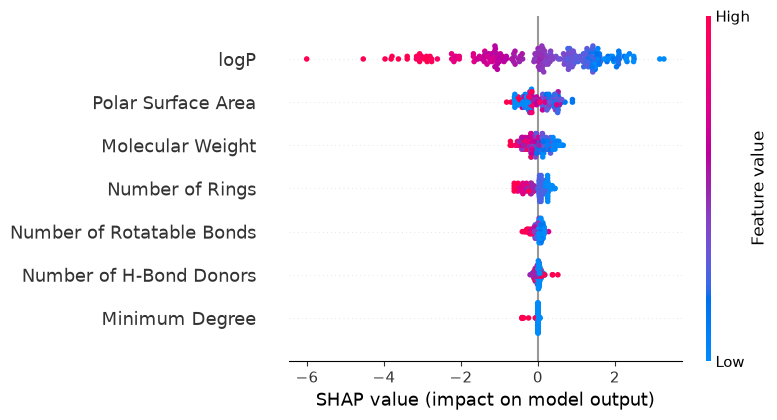

In [16]:
shap.summary_plot(shap_values, X_test, feature_names=new_features, show=False)
plt.gcf().savefig("figures/fe_shap_summary_7feat.pdf", bbox_inches="tight")
plt.show()


### 10d. SHAP bar plot — clean global ranking

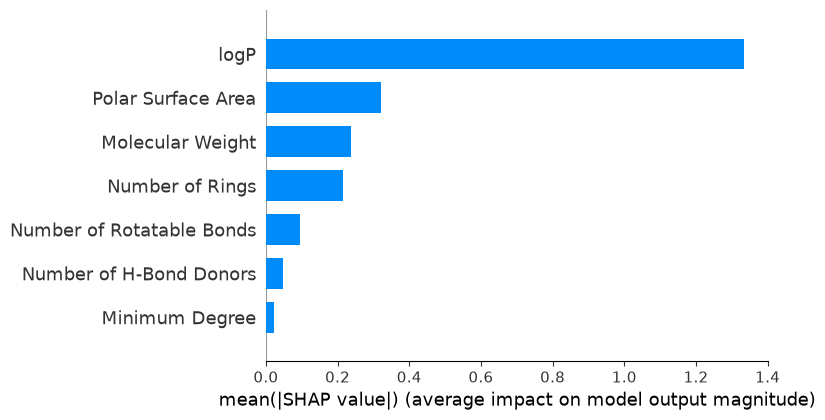

In [17]:
shap.summary_plot(shap_values, X_test, feature_names=new_features, plot_type="bar", show=False)
plt.gcf().savefig("figures/fe_shap_bar_7feat.pdf", bbox_inches="tight")
plt.show()


### 10e. One local explanation — a single molecule

SHAP's real power over `feature_importances_` is *per-prediction* explanations.
Pick the molecule with the biggest residual (where the model was most wrong)
and see what features drove that prediction.

In [18]:
# Molecule with the largest absolute residual
worst_idx_pos = np.argmax(np.abs(residuals7.values))
worst_row = X_test.iloc[worst_idx_pos]
worst_molecule = df.loc[X_test.index[worst_idx_pos], "Compound ID"]
print(f"Molecule: {worst_molecule}")
print(f"  Measured logS : {y_test.iloc[worst_idx_pos]:+.3f}")
print(f"  Predicted logS: {y_pred_xgb7[worst_idx_pos]:+.3f}")
print(f"  Residual      : {residuals7.iloc[worst_idx_pos]:+.3f}")
print(f"  logP          : {worst_row['logP']:+.3f}")
print()
print("SHAP contributions to this prediction (sorted by magnitude):")
contributions = pd.Series(shap_values[worst_idx_pos], index=new_features).sort_values(key=abs, ascending=False)
print(contributions.round(4))
print(f"\n(baseline = {baseline:.3f}, contributions sum to prediction shift of {contributions.sum():+.3f})")


Molecule: vamidothion
  Measured logS : +1.144
  Predicted logS: -2.682
  Residual      : +3.826
  logP          : +1.988

SHAP contributions to this prediction (sorted by magnitude):
logP                         0.4709
Number of Rings              0.4470
Molecular Weight            -0.3110
Number of Rotatable Bonds   -0.2917
Polar Surface Area           0.1113
Number of H-Bond Donors     -0.0727
Minimum Degree               0.0052
dtype: float32

(baseline = -3.041, contributions sum to prediction shift of +0.359)


## Interview takeaways from SHAP

1. **SHAP mean-|value| and XGBoost gain give the same top-1 (logP)** — that's a
   consistency check. If they disagreed, something would be off with the model.

2. **The ranking below logP can shift.** Gain measures how often + how much the
   *trees split* on a feature during training. SHAP measures how much each feature
   *actually shifts predictions* on the test set. A feature that's used in many
   splits but always ends up in leaves that don't move the prediction much will
   look important in gain and unimportant in SHAP. That's not a bug — they answer
   different questions.

3. **SHAP is in real logS units, gain is unitless (normalized to sum to 1).**
   If a feature has mean |SHAP| = 0.5, it moves predictions by ~0.5 log units on
   average — a directly interpretable quantity.

4. **The summary plot is the single best visualization** for global model behavior.
   Direction (red vs blue) tells you sign of effect, spread tells you magnitude,
   density tells you distribution. One chart, three axes of information.

5. **Local explanations** (cell 10e) are the killer feature. You can hand a chemist
   a per-molecule breakdown and say "the model predicted −5.2 for this compound;
   logP contributed −1.8, polar surface area contributed +0.4, ..." That's a
   defensible, actionable output — impossible with `feature_importances_` alone.